# Day 8/60 — Data Centers: GeoDNS, Failover & Synchronization

## System Design Series

**Topic:** In normal operation, GeoDNS geo-routes users to their nearest data center — x% to US-East, (100-x)% to US-West. On outage, all traffic redirects to the healthy DC.

**What we cover:**
- Normal operation architecture: CDN + User + DNS → LB → geo-routed DC1 / DC2
- Outage scenario: DC failure, traffic failover, and recovery timeline
- GeoDNS deep-dive: resolution flow + weighted traffic splits
- Data synchronization: replication strategies, lag, and cache consistency
- Test and deployment: multi-DC pipeline, canary releases, regional testing
- Technical challenges: availability tiers, RTO/RPO by strategy
- Architecture evolution and Day 8 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE    = '#4C72B0'
C_GREEN   = '#27AE60'
C_ORANGE  = '#DD8452'
C_RED     = '#C44E52'
C_TEAL    = '#2E86AB'
C_GRAY    = '#F8F9FA'
C_LB      = '#E67E22'
C_DB      = '#8E44AD'
C_SERVER  = '#4C72B0'
C_USER    = '#2E86AB'
C_DC1     = '#2980B9'   # blue   — US-East
C_DC2     = '#27AE60'   # green  — US-West
C_DNS     = '#8E44AD'   # purple — GeoDNS
C_FAIL    = '#E74C3C'   # red    — outage / failure
C_SYNC    = '#F39C12'   # amber  — data sync / replication

print("Libraries loaded. Day 8 ready.")


Libraries loaded. Day 8 ready.


### What this does

Loads Matplotlib and NumPy with the Day 8 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_DC1` | Blue | DC1 — US-East |
| `C_DC2` | Green | DC2 — US-West |
| `C_DNS` | Purple | GeoDNS service |
| `C_FAIL` | Red | Outage / failure state |
| `C_SYNC` | Amber | Data replication / sync |

Blue = east, green = west — a geographic convention held throughout all diagrams.

## 2. Normal Operation — GeoDNS Architecture

The reference architecture (matching the Day 8 diagram) shows:

- **CDN** (oval) — serves static assets to the browser
- **User box** — contains Web Browser and Mobile App
- **DNS** (oval) — resolves `api.mysite.com` → public IP `27.220.30.232`
- **Load Balancer** — receives all traffic at the public IP
- **Geo-routing** — two diagonal arrows branch to **DC1 (US-East)** and **DC2 (US-West)**
- Each DC has a **dashed inner cluster** of 3 web servers, plus **Databases** and **Caches**

> **GeoDNS** (also called geo-routing) is a DNS service that resolves domain names to different IP addresses depending on where the DNS query originates. US-East users get DC1's IP; US-West users get DC2's IP.

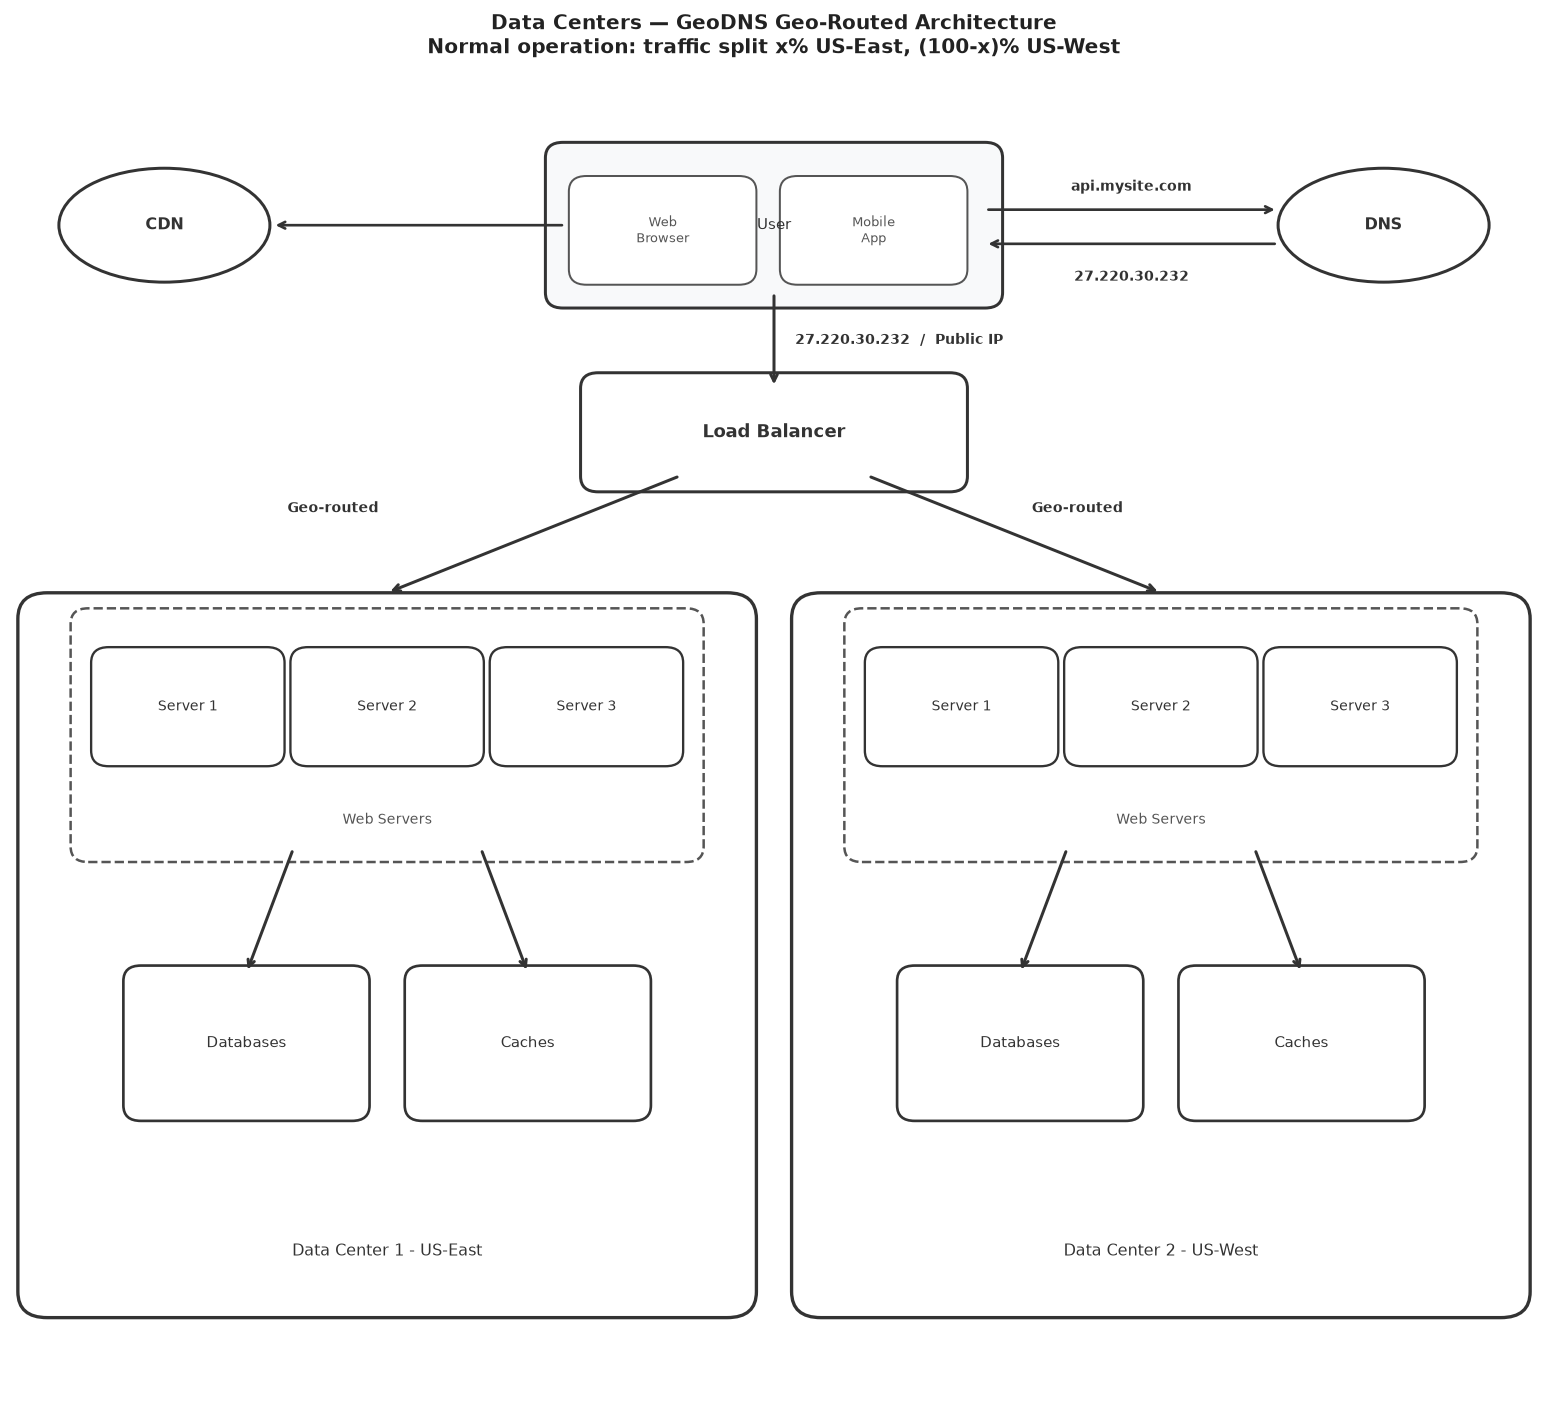

Architecture diagram done.


In [2]:
# Exact layout match to reference:
# CDN (oval, left) — User box (Web Browser + Mobile App) — DNS (oval, right)
# 27.220.30.232 Public IP arrow → Load Balancer
# LB → geo-routed diagonal arrows → DC1 (US-East) | DC2 (US-West)
# Each DC: solid outer box → dashed inner cluster (3 servers) → DB + Cache

fig, ax = plt.subplots(figsize=(13, 12))
ax.set_xlim(0, 13); ax.set_ylim(0, 13)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ── Helper: rounded rect ──────────────────────────────────────────────────────
def rbox(ax, x, y, w, h, label, color='#333', bg='white',
         fs=9.5, fw='bold', lw=1.8, linestyle='solid', sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.15',
                       facecolor=bg, edgecolor=color, lw=lw,
                       linestyle=linestyle)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight=fw, color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def oval(ax, x, y, rx, ry, label, color='#333', fs=9.5):
    e = plt.matplotlib.patches.Ellipse((x, y), rx * 2, ry * 2,
                                        facecolor='white', edgecolor=color,
                                        lw=1.8, zorder=3)
    ax.add_patch(e)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=color, zorder=4)

def arr(ax, x1, y1, x2, y2, color='#333', lw=1.8, label='',
        label_offset=(0.15, 0.15), label_ha='left', style='->'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw))
    if label:
        mx = (x1 + x2) / 2 + label_offset[0]
        my = (y1 + y2) / 2 + label_offset[1]
        ax.text(mx, my, label, ha=label_ha, va='center',
                fontsize=8.5, color=color, fontweight='bold')

# ════════════════════════════════════════════════════════════════
# ROW 1 — CDN  |  User (Web Browser + Mobile App)  |  DNS
# ════════════════════════════════════════════════════════════════
oval(ax, 1.3, 11.5, 0.9, 0.55, 'CDN', color='#333')

# User outer box
rbox(ax, 6.5, 11.5, 3.6, 1.3, 'User', color='#333', bg='#F8F9FA', fs=9, fw='normal')
# Inner components
rbox(ax, 5.55, 11.45, 1.3, 0.75, 'Web\nBrowser', color='#555', bg='white', fs=8, fw='normal', lw=1.2)
rbox(ax, 7.35, 11.45, 1.3, 0.75, 'Mobile\nApp',   color='#555', bg='white', fs=8, fw='normal', lw=1.2)

oval(ax, 11.7, 11.5, 0.9, 0.55, 'DNS', color='#333')

# User ↔ DNS
arr(ax, 8.3, 11.65, 10.8, 11.65, color='#333', lw=1.6,
    label='api.mysite.com', label_offset=(0.0, 0.22), label_ha='center', style='->')
arr(ax, 10.8, 11.32, 8.3, 11.32, color='#333', lw=1.6,
    label='27.220.30.232', label_offset=(0.0, -0.32), label_ha='center', style='->')

# User → CDN
arr(ax, 4.72, 11.5, 2.22, 11.5, color='#333', lw=1.6, style='->')

# ════════════════════════════════════════════════════════════════
# ROW 2 — Load Balancer
# ════════════════════════════════════════════════════════════════
rbox(ax, 6.5, 9.5, 3.0, 0.85, 'Load Balancer', color='#333', bg='white', fs=10.5)

# User → LB
arr(ax, 6.5, 10.85, 6.5, 9.93, color='#333', lw=1.8,
    label='27.220.30.232  /  Public IP',
    label_offset=(0.18, 0.0), label_ha='left')

# ════════════════════════════════════════════════════════════════
# ROW 3 — Two Data Centers
# ════════════════════════════════════════════════════════════════

# ── LB geo-routed diagonal arrows → each DC ──────────────────────
# Left diagonal: LB → DC1 centre-top
arr(ax, 5.7, 9.08, 3.2, 7.95, color='#333', lw=1.8,
    label='Geo-routed', label_offset=(-2.1, 0.25), label_ha='left')
# Right diagonal: LB → DC2 centre-top
arr(ax, 7.3, 9.08, 9.8, 7.95, color='#333', lw=1.8,
    label='Geo-routed', label_offset=(0.15, 0.25), label_ha='left')

# ── DC 1: US-East ─────────────────────────────────────────────────
dc1 = FancyBboxPatch((0.3, 1.2), 5.8, 6.5,
                     boxstyle='round,pad=0.25',
                     facecolor='white', edgecolor='#333', lw=2.0)
ax.add_patch(dc1)
ax.text(3.2, 1.55, 'Data Center 1 - US-East', ha='center',
        fontsize=9.5, color='#333', fontweight='normal')

# Dashed web-server cluster inside DC1
dc1_inner = FancyBboxPatch((0.65, 5.5), 5.1, 2.15,
                            boxstyle='round,pad=0.15',
                            facecolor='white', edgecolor='#555',
                            lw=1.5, linestyle='dashed')
ax.add_patch(dc1_inner)
ax.text(3.2, 5.72, 'Web Servers', ha='center',
        fontsize=8.5, color='#555', fontweight='normal')

for xi, lbl in [(1.5, 'Server 1'), (3.2, 'Server 2'), (4.9, 'Server 3')]:
    rbox(ax, xi, 6.85, 1.35, 0.85, lbl, color='#333', bg='white', fs=8.5, fw='normal', lw=1.4)

# Web Servers → DB and Cache (two arrows from dashed box bottom)
arr(ax, 2.4, 5.48, 2.0, 4.28, color='#333', lw=1.8)
arr(ax, 4.0, 5.48, 4.4, 4.28, color='#333', lw=1.8)

# DB and Cache nodes (cylinder-style with rounded rect)
rbox(ax, 2.0, 3.6, 1.8, 1.2, 'Databases', color='#333', bg='white', fs=9, fw='normal', lw=1.6)
rbox(ax, 4.4, 3.6, 1.8, 1.2, 'Caches',    color='#333', bg='white', fs=9, fw='normal', lw=1.6)

# ── DC 2: US-West ─────────────────────────────────────────────────
dc2 = FancyBboxPatch((6.9, 1.2), 5.8, 6.5,
                     boxstyle='round,pad=0.25',
                     facecolor='white', edgecolor='#333', lw=2.0)
ax.add_patch(dc2)
ax.text(9.8, 1.55, 'Data Center 2 - US-West', ha='center',
        fontsize=9.5, color='#333', fontweight='normal')

# Dashed web-server cluster inside DC2
dc2_inner = FancyBboxPatch((7.25, 5.5), 5.1, 2.15,
                            boxstyle='round,pad=0.15',
                            facecolor='white', edgecolor='#555',
                            lw=1.5, linestyle='dashed')
ax.add_patch(dc2_inner)
ax.text(9.8, 5.72, 'Web Servers', ha='center',
        fontsize=8.5, color='#555', fontweight='normal')

for xi, lbl in [(8.1, 'Server 1'), (9.8, 'Server 2'), (11.5, 'Server 3')]:
    rbox(ax, xi, 6.85, 1.35, 0.85, lbl, color='#333', bg='white', fs=8.5, fw='normal', lw=1.4)

# Web Servers → DB and Cache
arr(ax, 9.0,  5.48, 8.6,  4.28, color='#333', lw=1.8)
arr(ax, 10.6, 5.48, 11.0, 4.28, color='#333', lw=1.8)

rbox(ax, 8.6,  3.6, 1.8, 1.2, 'Databases', color='#333', bg='white', fs=9, fw='normal', lw=1.6)
rbox(ax, 11.0, 3.6, 1.8, 1.2, 'Caches',    color='#333', bg='white', fs=9, fw='normal', lw=1.6)

ax.set_title('Data Centers — GeoDNS Geo-Routed Architecture\n'
             'Normal operation: traffic split x% US-East, (100-x)% US-West',
             fontsize=12, fontweight='bold', color='#222', pad=10)

plt.tight_layout()
plt.savefig('/tmp/sd_day8_normal.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram done.")


### What this shows

The diagram exactly matches the Day 8 reference image structure:

**Top row:** CDN oval ← User (Web Browser + Mobile App) → DNS oval  
**DNS exchange:** `api.mysite.com` query out, `27.220.30.232` IP response back  
**Middle:** Public IP `27.220.30.232` arrow down to the Load Balancer  
**Geo-routing:** Two diagonal arrows labelled "Geo-routed" fan out to each DC  
**Each DC:** Solid outer rectangle, dashed inner cluster with Server 1/2/3, then two arrows down to Databases and Caches

The traffic split is `x% → DC1` and `(100-x)% → DC2`. Both DCs are active simultaneously during normal operation — this is not a hot-standby, it is an active-active split.

## 3. Outage Scenario — Failover to Healthy DC

When a data center fails, the system must:
1. **Detect** the failure (health check endpoint returns non-2xx or times out)
2. **Stop routing** new traffic to the failed DC (GeoDNS removes it from responses)
3. **Absorb** 100% of traffic at the surviving DC (autoscaler adds capacity)
4. **Promote** the DB replica at the surviving DC to primary
5. **Recover** DC1 and rebalance traffic when healthy

The critical variable is **GeoDNS TTL** — the duration for which clients cache the DNS response. A TTL of 30-60 seconds means failover completes in under 2 minutes. A TTL of 300 seconds means up to 5 minutes of requests may still go to the failed DC.

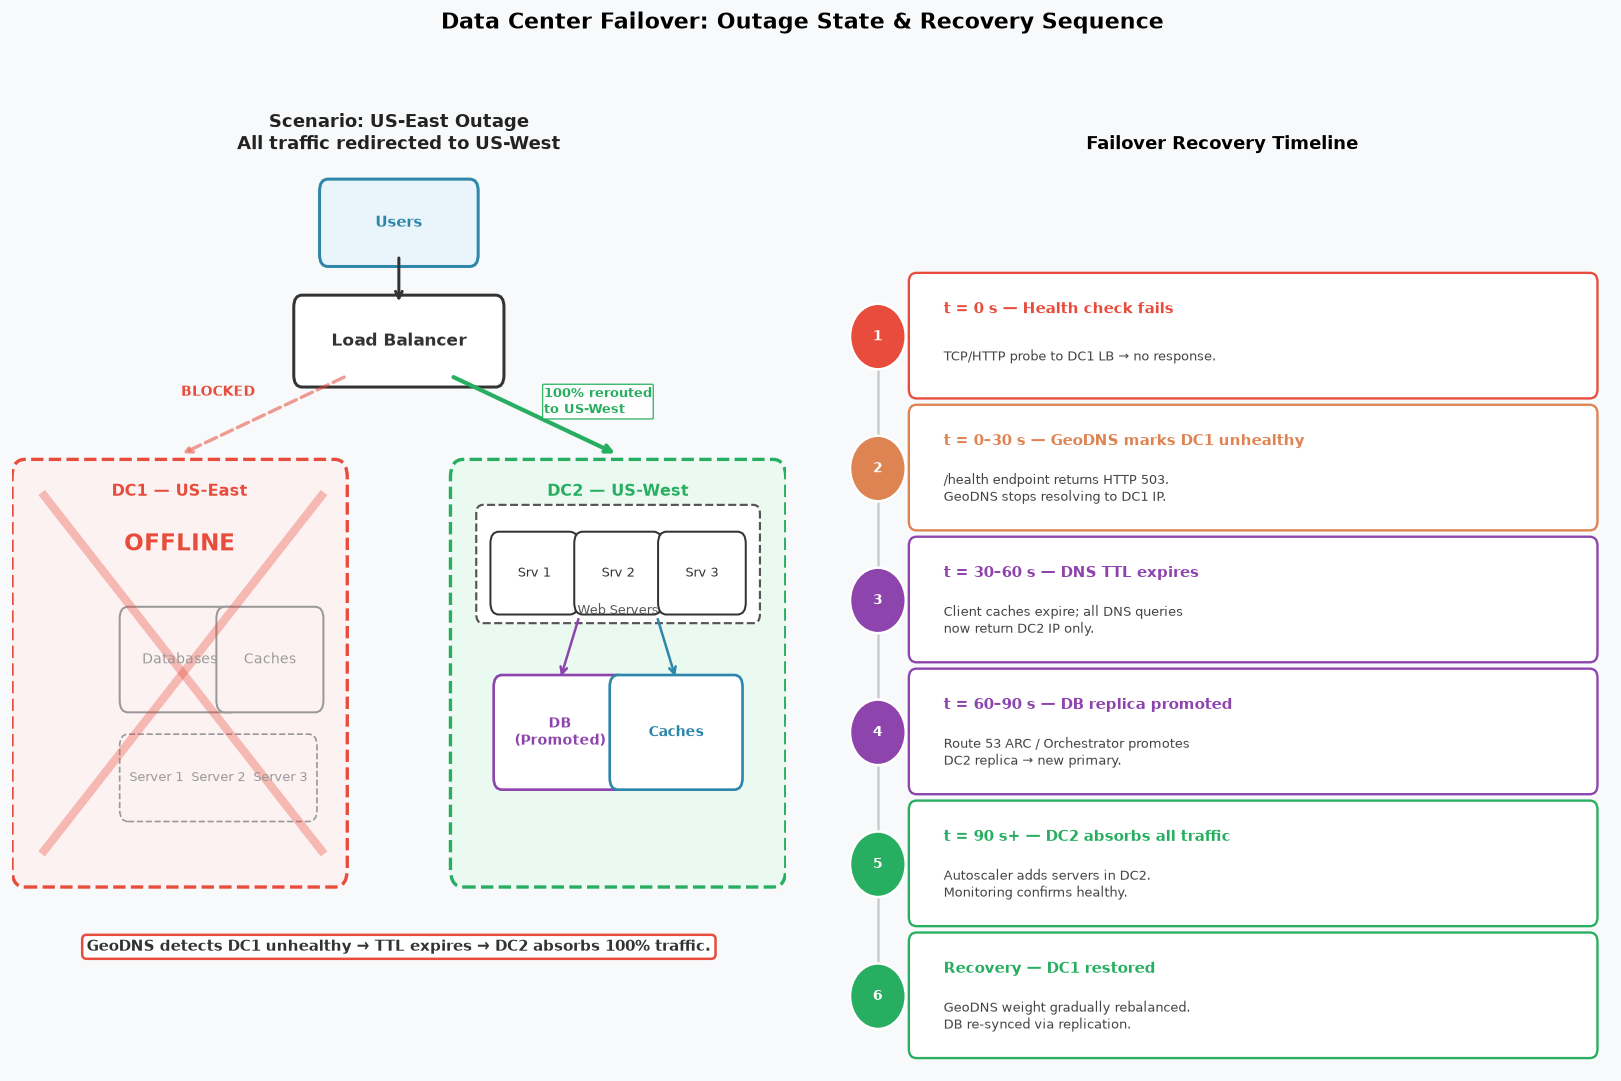

In [3]:
# DC outage failover: US-East goes down → 100% traffic rerouted to US-West
# Same structural layout as normal, but DC1 marked OFFLINE with X

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color='#333', bg='white',
         fs=9.5, fw='bold', lw=1.8, linestyle='solid', sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=bg, edgecolor=color, lw=lw, linestyle=linestyle)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs, fontweight=fw, color=color)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1 + x2) / 2 + 0.15, (y1 + y2) / 2 + 0.15
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.92))

# ── Panel A: outage state ─────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor('white')
ax.set_title('Scenario: US-East Outage\nAll traffic redirected to US-West',
             fontsize=11, fontweight='bold', color='#222')

# User + LB (top)
rbox(ax, 6.0, 9.3, 2.2, 0.7, 'Users', C_USER, bg='#EAF4FB', fs=9)
rbox(ax, 6.0, 8.0, 3.0, 0.75, 'Load Balancer', '#333', bg='white', fs=10)
arr(ax, 6.0, 8.95, 6.0, 8.40, '', '#333', lw=1.8)

# LB → DC1 (dashed, blocked)
ax.annotate('', xy=(2.6, 6.75), xytext=(5.2, 7.62),
            arrowprops=dict(arrowstyle='->', color=C_FAIL, lw=2.0,
                            linestyle='dashed', alpha=0.55))
ax.text(3.2, 7.4, 'BLOCKED', ha='center', fontsize=8.5,
        color=C_FAIL, fontweight='bold')

# LB → DC2 (solid, all traffic)
arr(ax, 6.8, 7.62, 9.4, 6.75, '100% rerouted\nto US-West', C_GREEN, lw=2.5)

# DC1 — failed box
dc1_bg = FancyBboxPatch((0.2, 2.2), 4.8, 4.3,
                         boxstyle='round,pad=0.2',
                         facecolor='#FDF2F2', edgecolor=C_FAIL, lw=2.0,
                         linestyle='--')
ax.add_patch(dc1_bg)
ax.text(2.6, 6.3, 'DC1 — US-East', ha='center',
        fontsize=9.5, fontweight='bold', color=C_FAIL)
ax.text(2.6, 5.7, 'OFFLINE', ha='center',
        fontsize=14, fontweight='bold', color=C_FAIL)
ax.plot([0.5, 4.8], [2.4, 6.3], color=C_FAIL, lw=5, alpha=0.35)
ax.plot([0.5, 4.8], [6.3, 2.4], color=C_FAIL, lw=5, alpha=0.35)

rbox(ax, 2.6, 4.5, 1.6, 0.9, 'Databases', '#999', bg='#FDF2F2', fs=8.5, fw='normal', lw=1.2)
rbox(ax, 4.0, 4.5, 1.4, 0.9, 'Caches',    '#999', bg='#FDF2F2', fs=8.5, fw='normal', lw=1.2)
rbox(ax, 3.2, 3.2, 2.8, 0.7, 'Server 1  Server 2  Server 3',
     '#999', bg='#FDF2F2', fs=7.5, fw='normal', lw=1.0, linestyle='dashed')

# DC2 — healthy
dc2_bg = FancyBboxPatch((7.0, 2.2), 4.8, 4.3,
                         boxstyle='round,pad=0.2',
                         facecolor='#EAFAF1', edgecolor=C_DC2, lw=2.0,
                         linestyle='--')
ax.add_patch(dc2_bg)
ax.text(9.4, 6.3, 'DC2 — US-West', ha='center',
        fontsize=9.5, fontweight='bold', color=C_DC2)

# Dashed inner cluster DC2
dc2_inner = FancyBboxPatch((7.3, 5.0), 4.2, 1.1,
                            boxstyle='round,pad=0.1', facecolor='white',
                            edgecolor='#555', lw=1.3, linestyle='dashed')
ax.add_patch(dc2_inner)
for xi, lbl in [(8.1, 'Srv 1'), (9.4, 'Srv 2'), (10.7, 'Srv 3')]:
    rbox(ax, xi, 5.45, 1.1, 0.65, lbl, '#333', bg='white', fs=8, fw='normal', lw=1.2)
ax.text(9.4, 5.0, 'Web Servers', ha='center', fontsize=7.5, color='#555')

arr(ax, 8.8, 4.98, 8.5, 4.28, '', C_DB, lw=1.5)
arr(ax, 10.0,4.98, 10.3,4.28, '', C_TEAL, lw=1.5)
rbox(ax, 8.5,  3.7, 1.8, 1.0, 'DB\n(Promoted)', C_DB,  bg='white', fs=8.5, fw='bold', lw=1.6)
rbox(ax, 10.3, 3.7, 1.8, 1.0, 'Caches',         C_TEAL, bg='white', fs=8.5, fw='bold', lw=1.6)

ax.text(6.0, 1.3,
        'GeoDNS detects DC1 unhealthy → TTL expires → DC2 absorbs 100% traffic.',
        ha='center', fontsize=9, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_FAIL, lw=1.5))

# ── Panel B: recovery timeline ────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Failover Recovery Timeline', fontsize=11, fontweight='bold')

steps = [
    ('t = 0 s',    'Health check fails',
     'TCP/HTTP probe to DC1 LB → no response.', C_FAIL),
    ('t = 0–30 s', 'GeoDNS marks DC1 unhealthy',
     '/health endpoint returns HTTP 503.\nGeoDNS stops resolving to DC1 IP.', C_ORANGE),
    ('t = 30–60 s','DNS TTL expires',
     'Client caches expire; all DNS queries\nnow return DC2 IP only.', C_DNS),
    ('t = 60–90 s','DB replica promoted',
     'Route 53 ARC / Orchestrator promotes\nDC2 replica → new primary.', C_DB),
    ('t = 90 s+',  'DC2 absorbs all traffic',
     'Autoscaler adds servers in DC2.\nMonitoring confirms healthy.', C_DC2),
    ('Recovery',   'DC1 restored',
     'GeoDNS weight gradually rebalanced.\nDB re-synced via replication.', C_GREEN),
]

y0 = 9.5
for i, (ts, title, body, color) in enumerate(steps):
    y0 -= 1.45
    circ = plt.Circle((0.55, y0), 0.36, facecolor=color,
                       edgecolor='white', lw=1.5, zorder=5)
    ax.add_patch(circ)
    ax.text(0.55, y0, str(i + 1), ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=6)
    r = FancyBboxPatch((1.05, y0 - 0.58), 8.7, 1.18,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    ax.text(1.4, y0 + 0.3, f'{ts} — {title}', ha='left', va='center',
            fontsize=9, fontweight='bold', color=color)
    ax.text(1.4, y0 - 0.22, body, ha='left', va='center',
            fontsize=8, color='#444')
    if i < 5:
        ax.plot([0.55, 0.55], [y0 - 0.38, y0 - 1.07],
                color='#CCC', lw=1.5, zorder=0)

plt.suptitle('Data Center Failover: Outage State & Recovery Sequence',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig('/tmp/sd_day8_failover.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Outage state:**  
DC1 (US-East) is shown with a red dashed border and a large X. The dashed arrow from the LB to DC1 is labelled BLOCKED. All traffic (100%) is routed via a solid green arrow to DC2 (US-West), which has its DB replica promoted to primary.

**Right — Recovery timeline (6 steps):**  
Numbered steps from the initial health check failure (t=0) through DNS TTL expiry, DB promotion, DC2 absorbing full load, and finally DC1 recovery with gradual rebalancing. Each step has an estimated time window — total failover completes in 60-90 seconds with automated tooling.

## 4. GeoDNS Deep-Dive

> "GeoDNS is a DNS service that allows domain names to be resolved to IP addresses based on the location of a user." — Day 8

**How it works:**
1. The user's browser queries its local DNS resolver
2. The resolver forwards to the GeoDNS authority (e.g. Route 53, NS1)
3. The GeoDNS authority looks up the query's source IP in a GeoIP database
4. It returns the IP of the nearest healthy DC

**Traffic splitting:** GeoDNS supports weighted routing — you can set DC1=70%, DC2=30% to match your user distribution, then adjust weights dynamically as traffic patterns change or DCs fail.

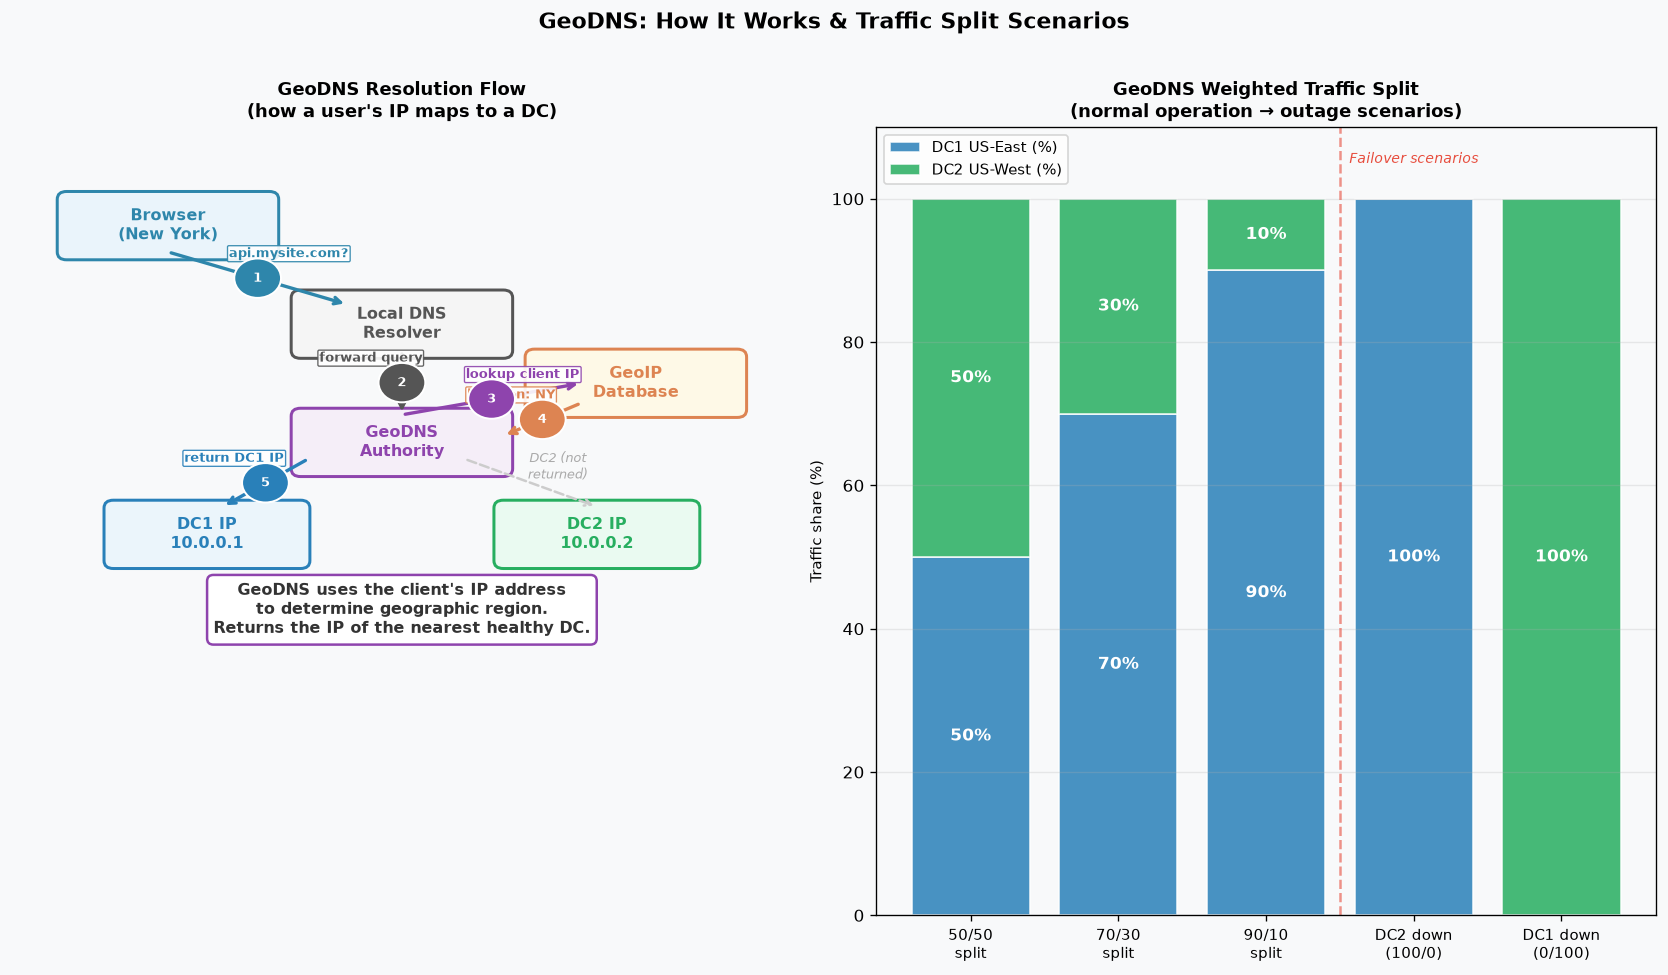

In [4]:
# GeoDNS deep-dive: how DNS resolution works + weighted routing

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: GeoDNS resolution flow ─────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('GeoDNS Resolution Flow\n(how a user\'s IP maps to a DC)', fontsize=11,
             fontweight='bold')

def node(ax, x, y, w, h, label, color, bg, sub='', fs=9.5):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs, fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def step_arr(ax, x1, y1, x2, y2, num, label, color):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    circ = plt.Circle(((x1+x2)/2, (y1+y2)/2), 0.30,
                       facecolor=color, edgecolor='white', lw=1.2, zorder=5)
    ax.add_patch(circ)
    ax.text((x1+x2)/2, (y1+y2)/2, str(num), ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=6)
    offset_x = 0.4 if x2 > x1 else -0.4
    ax.text((x1+x2)/2 + offset_x, (y1+y2)/2 + 0.32, label,
            ha='center', fontsize=8, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                      edgecolor=color, lw=0.8, alpha=0.9))

actors = [
    (2.0, 10.5, 2.6, 0.8, 'Browser\n(New York)', C_USER,   '#EAF4FB'),
    (5.0,  9.0, 2.6, 0.8, 'Local DNS\nResolver',  '#555',   '#F5F5F5'),
    (5.0,  7.2, 2.6, 0.8, 'GeoDNS\nAuthority',   C_DNS,    '#F5EEF8'),
    (8.0,  8.1, 2.6, 0.8, 'GeoIP\nDatabase',     C_ORANGE, '#FEF9E7'),
    (2.5,  5.8, 2.4, 0.8, 'DC1 IP\n10.0.0.1',   C_DC1,   '#EBF5FB'),
    (7.5,  5.8, 2.4, 0.8, 'DC2 IP\n10.0.0.2',   C_DC2,   '#EAFAF1'),
]
for args in actors:
    node(ax, *args)

step_arr(ax, 2.0, 10.1, 4.3, 9.3, 1, 'api.mysite.com?', C_USER)
step_arr(ax, 5.0, 8.6,  5.0, 7.62, 2, 'forward query', '#555')
step_arr(ax, 5.0, 7.62, 7.3, 8.1, 3, 'lookup client IP', C_DNS)
step_arr(ax, 7.3, 7.8, 6.3, 7.3, 4, 'location: NY', C_ORANGE)
# NY → DC1
step_arr(ax, 3.8, 6.95, 2.7, 6.22, 5, 'return DC1 IP', C_DC1)
ax.annotate('', xy=(7.5, 6.22), xytext=(5.8, 6.95),
            arrowprops=dict(arrowstyle='->', color='#CCC', lw=1.5, linestyle='dashed'))
ax.text(7.0, 6.65, 'DC2 (not\nreturned)', ha='center', fontsize=7.5,
        color='#AAA', fontstyle='italic')

ax.text(5.0, 4.3,
        'GeoDNS uses the client\'s IP address\nto determine geographic region.\n'
        'Returns the IP of the nearest healthy DC.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_DNS, lw=1.5))

# ── Right: weighted traffic split bar chart ───────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

scenarios = ['50/50\nsplit', '70/30\nsplit', '90/10\nsplit',
             'DC2 down\n(100/0)', 'DC1 down\n(0/100)']
dc1_pct = [50, 70, 90, 100,  0]
dc2_pct = [50, 30, 10,   0, 100]

x = np.arange(len(scenarios))
bars1 = ax.bar(x, dc1_pct, color=C_DC1, edgecolor='white',
               alpha=0.85, label='DC1 US-East (%)')
bars2 = ax.bar(x, dc2_pct, bottom=dc1_pct, color=C_DC2,
               edgecolor='white', alpha=0.85, label='DC2 US-West (%)')

for i, (b1, b2, d1, d2) in enumerate(zip(bars1, bars2, dc1_pct, dc2_pct)):
    if d1 > 0:
        ax.text(i, d1 / 2, f'{d1}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    if d2 > 0:
        ax.text(i, d1 + d2 / 2, f'{d2}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x); ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('Traffic share (%)', fontsize=9)
ax.set_ylim(0, 110)
ax.set_title('GeoDNS Weighted Traffic Split\n(normal operation → outage scenarios)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)

ax.axvline(2.5, color=C_FAIL, lw=1.5, linestyle='--', alpha=0.6)
ax.text(3.0, 105, 'Failover scenarios', ha='center',
        fontsize=8.5, color=C_FAIL, fontstyle='italic')

plt.suptitle('GeoDNS: How It Works & Traffic Split Scenarios',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day8_geodns.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — GeoDNS resolution flow:**  
5-step numbered sequence from browser query → local resolver → GeoDNS authority → GeoIP database lookup → return of DC1 IP (for a New York user). The dashed grey arrow shows DC2 is not returned — it remains invisible to this user.

**Right — Weighted traffic split scenarios:**  
Stacked bars across 5 scenarios: 50/50, 70/30, 90/10 splits for normal operation, then 100/0 and 0/100 for failover states. The dashed red vertical line separates normal operation from outage scenarios. This illustrates how the same GeoDNS mechanism handles both routine traffic distribution and emergency failover.

## 5. Data Synchronization

> "Users from different regions could use different databases as well as caches. In failover cases, traffic might be routed to a data center where data is unavailable. Common strategy is to replicate the data across multiple data centers." — Day 8

Data sync is the hardest multi-DC challenge because different parts of the stack (DB, cache, session store) have different consistency requirements:

| Layer | Sync strategy | Acceptable lag |
|---|---|---|
| Database | Async replication (Active-Passive) | 10-200 ms |
| Cache | Cross-DC invalidation or short TTL | 0-5 s (self-healing) |
| Session store | Replicated Redis or per-DC with re-auth | 0 s (must be consistent) |

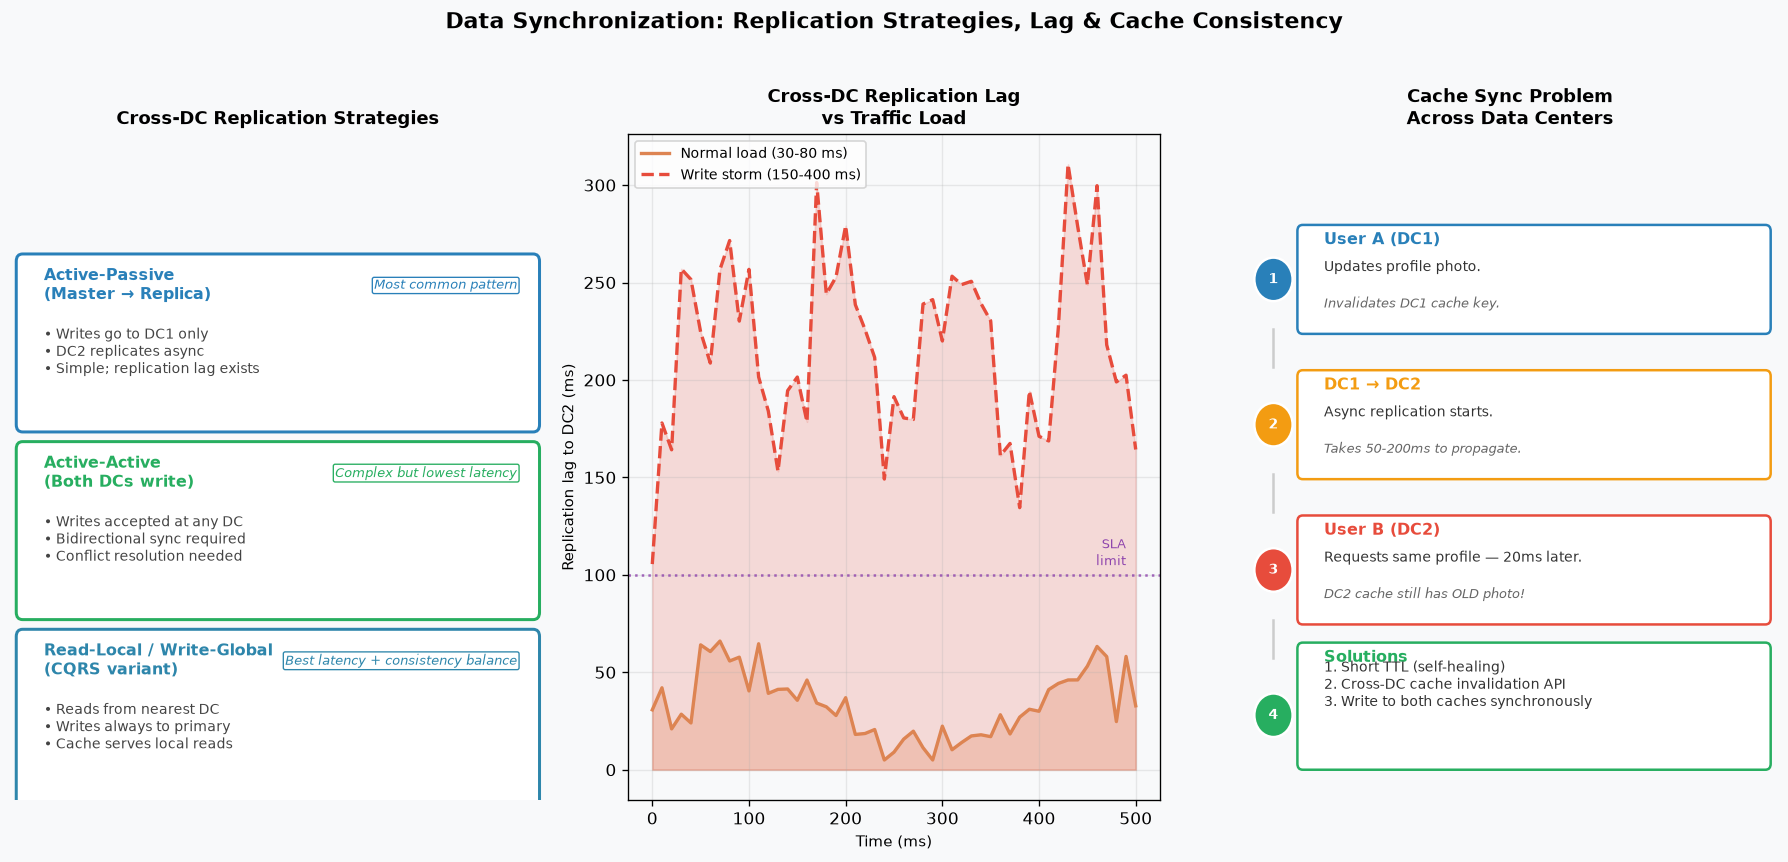

In [5]:
# Data synchronization: the hardest multi-DC challenge

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: replication strategies timeline ────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Cross-DC Replication Strategies', fontsize=11, fontweight='bold')

strategies = [
    ('Active-Passive\n(Master → Replica)',
     '• Writes go to DC1 only\n• DC2 replicates async\n• Simple; replication lag exists',
     C_DC1, 'Most common pattern'),
    ('Active-Active\n(Both DCs write)',
     '• Writes accepted at any DC\n• Bidirectional sync required\n• Conflict resolution needed',
     C_DC2, 'Complex but lowest latency'),
    ('Read-Local / Write-Global\n(CQRS variant)',
     '• Reads from nearest DC\n• Writes always to primary\n• Cache serves local reads',
     C_TEAL, 'Best latency + consistency balance'),
]

y0 = 10.5
for (title, body, color, tag) in strategies:
    y0 -= 3.1
    r = FancyBboxPatch((0.2, y0 - 1.2), 9.6, 2.7,
                       boxstyle='round,pad=0.12',
                       facecolor='white', edgecolor=color, lw=1.8)
    ax.add_patch(r)
    ax.text(0.6, y0 + 1.1, title, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.6, y0 + 0.0, body, ha='left', va='center',
            fontsize=8.5, color='#444')
    ax.text(9.5, y0 + 1.1, tag, ha='right', va='center',
            fontsize=7.5, color=color, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor=color, lw=0.8))

# ── Middle: replication lag impact ────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

np.random.seed(8)
time_ms  = np.arange(0, 501, 10)

# Normal async lag: 10-80ms
lag_normal = np.clip(
    30 + 20 * np.sin(time_ms / 60) + np.random.normal(0, 8, len(time_ms)),
    5, 120)

# Under write storm: spikes to 200-400ms
lag_storm  = np.clip(
    150 + 100 * np.abs(np.sin(time_ms / 40)) + np.random.normal(0, 25, len(time_ms)),
    20, 450)

ax.fill_between(time_ms, lag_normal, alpha=0.25, color=C_ORANGE)
ax.plot(time_ms, lag_normal, '-', color=C_ORANGE, lw=2.0,
        label='Normal load (30-80 ms)')

ax.fill_between(time_ms, lag_storm, alpha=0.18, color=C_FAIL)
ax.plot(time_ms, lag_storm, '--', color=C_FAIL, lw=2.0,
        label='Write storm (150-400 ms)')

ax.axhline(100, color=C_DNS, lw=1.5, linestyle=':', alpha=0.8)
ax.text(490, 105, 'SLA\nlimit', ha='right', fontsize=8, color=C_DNS)

ax.set_xlabel('Time (ms)', fontsize=9)
ax.set_ylabel('Replication lag to DC2 (ms)', fontsize=9)
ax.set_title('Cross-DC Replication Lag\nvs Traffic Load', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)

# ── Right: cache sync challenge ───────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Cache Sync Problem\nAcross Data Centers', fontsize=11, fontweight='bold')

steps = [
    ('User A (DC1)', 'Updates profile photo.',
     'Invalidates DC1 cache key.', C_DC1),
    ('DC1 → DC2', 'Async replication starts.',
     'Takes 50-200ms to propagate.', C_SYNC),
    ('User B (DC2)', 'Requests same profile — 20ms later.',
     'DC2 cache still has OLD photo!', C_FAIL),
    ('Solutions', '1. Short TTL (self-healing)\n'
     '2. Cross-DC cache invalidation API\n'
     '3. Write to both caches synchronously',
     '', C_GREEN),
]

y0 = 10.5
for i, (actor, event, detail, color) in enumerate(steps):
    y0 -= 2.4
    circ = plt.Circle((0.55, y0 + 0.5), 0.36, facecolor=color,
                       edgecolor='white', lw=1.5, zorder=5)
    ax.add_patch(circ)
    ax.text(0.55, y0 + 0.5, str(i + 1), ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=6)
    h = 1.9 if i == 3 else 1.6
    r = FancyBboxPatch((1.1, y0 - 0.3), 8.7, h,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(1.5, y0 + h - 0.45, actor, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(1.5, y0 + h - 0.9,  event, ha='left', va='center',
            fontsize=8.5, color='#333')
    if detail:
        ax.text(1.5, y0 + 0.1, detail, ha='left', va='center',
                fontsize=8, color='#666', fontstyle='italic')
    if i < 3:
        ax.plot([0.55, 0.55], [y0 - 0.32, y0 - 0.95],
                color='#CCC', lw=1.5, zorder=0)

plt.suptitle('Data Synchronization: Replication Strategies, Lag & Cache Consistency',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day8_datasync.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Replication strategy cards:**  
Three approaches — Active-Passive (simple, most common), Active-Active (complex, lowest write latency), and Read-Local/Write-Global (CQRS variant, best balance). Each card lists pros/cons and use cases.

**Middle — Replication lag over time:**  
Under normal load (orange), lag stays between 30-80 ms. Under a write storm (red dashed), lag spikes to 150-400 ms. The purple dotted line marks the SLA limit. Data written during a lag spike may not yet be visible at DC2 — this is the operational definition of eventual consistency.

**Right — Cache consistency problem:**  
4-step sequence showing the race condition: User A updates their profile in DC1, DC1 cache is invalidated, but the async replication hasn't reached DC2 yet. User B reads from DC2 and gets the stale old photo. Three solutions are listed: short TTL, cross-DC invalidation API, or synchronous dual-write.

## 6. Test and Deployment

> "With multi data server setup, it is important to test your website/app at different locations." — Day 8

Multi-DC deployment must be **sequential and verified** — deploying to all DCs simultaneously risks a bad build taking down everything at once.

**Safe multi-DC deploy sequence:**
1. Build + unit tests
2. Deploy to staging (single DC)
3. Integration + smoke tests
4. Deploy to DC1 (canary: 5% of traffic first)
5. Monitor DC1 for 10-30 minutes
6. Deploy to DC2 if DC1 is healthy
7. Monitor DC2 + rollback path ready

**Testing per region:** Geo-specific content (language, currency, compliance) must be validated against each region separately — a US deploy that passes all tests may break EU-specific GDPR consent flows.

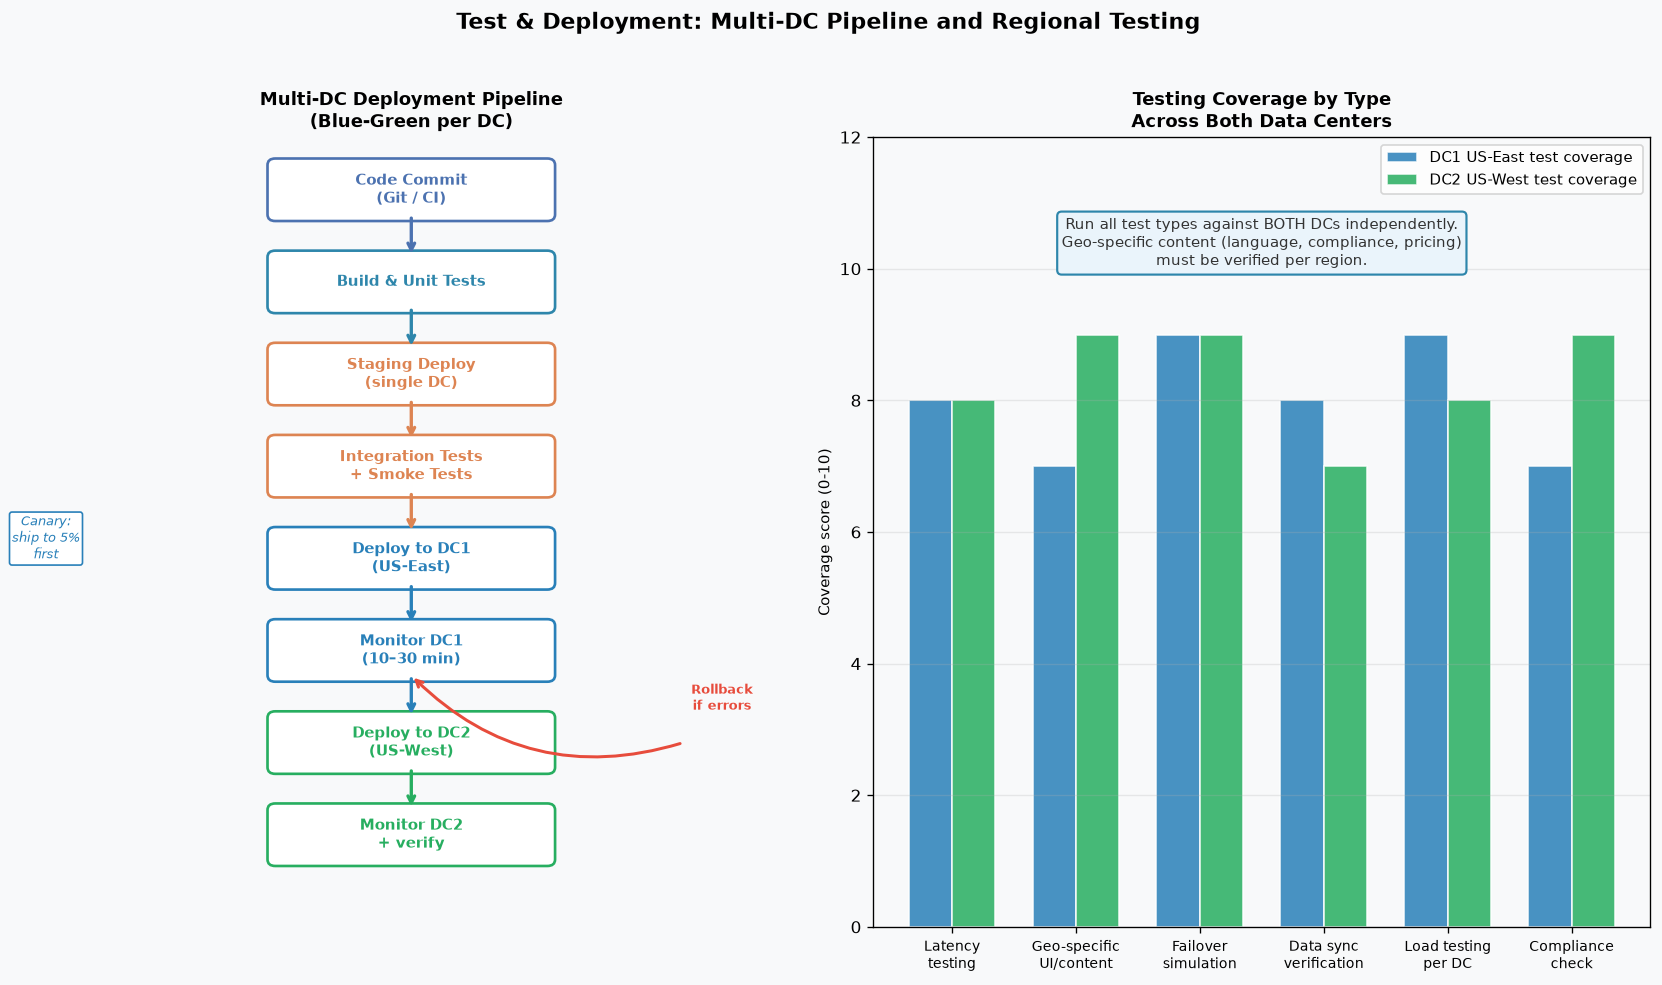

In [6]:
# Test and deployment across multiple data centers

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: deployment pipeline across DCs ─────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Multi-DC Deployment Pipeline\n(Blue-Green per DC)', fontsize=11, fontweight='bold')

def pbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.1',
                       facecolor=bg, edgecolor=color, lw=1.6)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.25, sub, ha='center', va='center',
                fontsize=7, color=color, alpha=0.85)

def parr(ax, x1, y1, x2, y2, color, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    if label:
        ax.text((x1+x2)/2 + 0.18, (y1+y2)/2, label, ha='left',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.9))

pipeline = [
    (5.0, 11.2, 3.5, 0.75, 'Code Commit\n(Git / CI)',         C_BLUE),
    (5.0,  9.8, 3.5, 0.75, 'Build & Unit Tests',              C_TEAL),
    (5.0,  8.4, 3.5, 0.75, 'Staging Deploy\n(single DC)',     C_ORANGE),
    (5.0,  7.0, 3.5, 0.75, 'Integration Tests\n+ Smoke Tests', C_ORANGE),
    (5.0,  5.6, 3.5, 0.75, 'Deploy to DC1\n(US-East)',        C_DC1),
    (5.0,  4.2, 3.5, 0.75, 'Monitor DC1\n(10–30 min)',        C_DC1),
    (5.0,  2.8, 3.5, 0.75, 'Deploy to DC2\n(US-West)',        C_DC2),
    (5.0,  1.4, 3.5, 0.75, 'Monitor DC2\n+ verify',          C_DC2),
]

for i, (x, y, w, h, lbl, col) in enumerate(pipeline):
    pbox(ax, x, y, w, h, lbl, col)
    if i < len(pipeline) - 1:
        parr(ax, x, y - 0.38, x, pipeline[i+1][1] + 0.38, col)

# Rollback arrow
ax.annotate('', xy=(5.0, 3.82), xytext=(8.5, 2.8),
            arrowprops=dict(arrowstyle='->', color=C_FAIL, lw=1.8,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(9.0, 3.3, 'Rollback\nif errors', ha='center', fontsize=8,
        color=C_FAIL, fontweight='bold')

# Canary note
ax.text(0.3, 5.6, 'Canary:\nship to 5%\nfirst', ha='center',
        fontsize=7.5, color=C_DC1, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=C_DC1, lw=1.0))

# ── Right: testing strategy across regions ────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

test_types = [
    'Latency\ntesting', 'Geo-specific\nUI/content', 'Failover\nsimulation',
    'Data sync\nverification', 'Load testing\nper DC', 'Compliance\ncheck'
]
dc1_scores = [8, 7, 9, 8, 9, 7]
dc2_scores = [8, 9, 9, 7, 8, 9]

x = np.arange(len(test_types)); w = 0.35
ax.bar(x - w/2, dc1_scores, width=w, color=C_DC1, alpha=0.85,
       edgecolor='white', label='DC1 US-East test coverage')
ax.bar(x + w/2, dc2_scores, width=w, color=C_DC2, alpha=0.85,
       edgecolor='white', label='DC2 US-West test coverage')

ax.set_xticks(x); ax.set_xticklabels(test_types, fontsize=8.5)
ax.set_ylabel('Coverage score (0-10)', fontsize=9)
ax.set_ylim(0, 12)
ax.set_title('Testing Coverage by Type\nAcross Both Data Centers', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)

ax.text(0.5, 0.90,
        'Run all test types against BOTH DCs independently.\n'
        'Geo-specific content (language, compliance, pricing)\nmust be verified per region.',
        ha='center', va='top', transform=ax.transAxes, fontsize=9,
        color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.3))

plt.suptitle('Test & Deployment: Multi-DC Pipeline and Regional Testing',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day8_testdeploy.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Deployment pipeline:**  
8-step sequential pipeline from code commit through staging, DC1 deploy (with canary note), DC1 monitoring, DC2 deploy, and DC2 verification. A rollback arrow loops back from DC2 to DC1 for emergency reversion. The canary label (5% first) reminds that DC1 gets a gradual rollout, not a hard cutover.

**Right — Testing coverage by type:**  
Grouped bars for 6 test categories (latency, geo-specific UI, failover simulation, data sync verification, load testing, compliance) scored per DC. Both DCs must achieve near-equal coverage — gaps in one DC's test suite are production risk.

## 7. Technical Challenges: Availability & Recovery Objectives

The three technical challenges from the Day 8 content each have quantifiable metrics:

**Traffic Redirection:** GeoDNS TTL of 30-60s → failover in under 2 minutes  
**Data Sync:** Replication lag defines RPO (Recovery Point Objective) — how much data may be lost on failover  
**Test & Deploy:** Pipeline gate time defines RTO (Recovery Time Objective) — how quickly you can push a fix after an incident

**Availability tiers (the 'nines'):**
- 99.9% = 8.76 hours/year downtime (single DC)
- 99.99% = 52.6 minutes/year (active-passive multi-DC)
- 99.999% = 5.26 minutes/year (active-active multi-DC)
- 99.9999% = 31.5 seconds/year (global distributed)

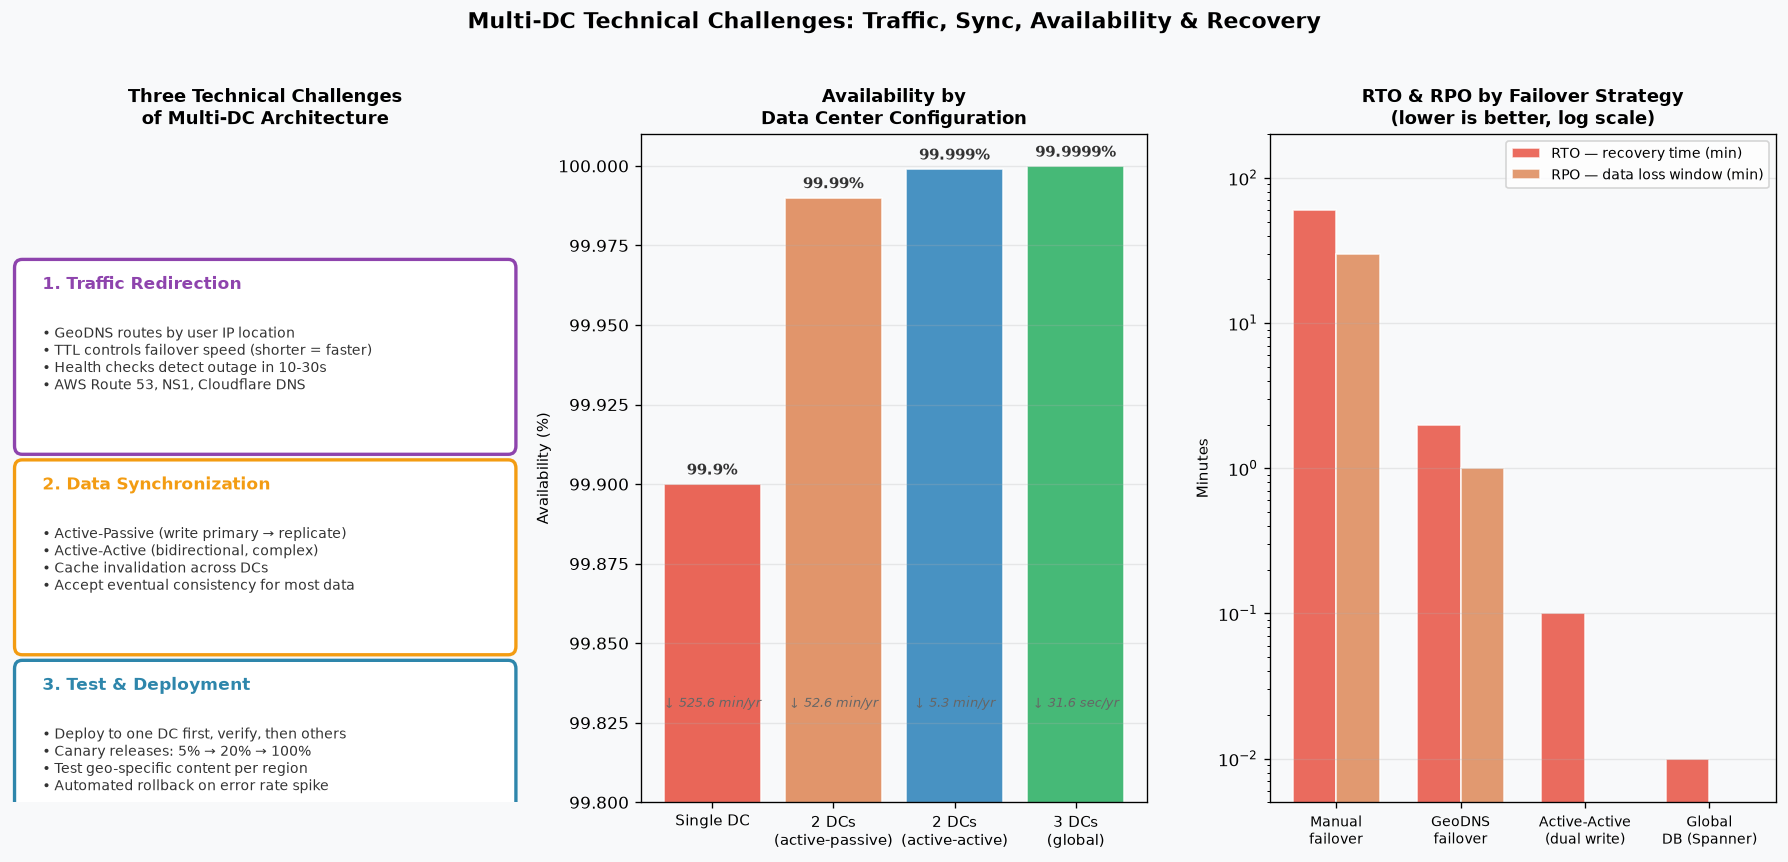

In [7]:
# Technical challenges summary + latency + availability impact

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: 3 technical challenges card view ────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Three Technical Challenges\nof Multi-DC Architecture', fontsize=11, fontweight='bold')

challenges = [
    ('1. Traffic Redirection',
     '• GeoDNS routes by user IP location\n'
     '• TTL controls failover speed (shorter = faster)\n'
     '• Health checks detect outage in 10-30s\n'
     '• AWS Route 53, NS1, Cloudflare DNS',
     C_DNS),
    ('2. Data Synchronization',
     '• Active-Passive (write primary → replicate)\n'
     '• Active-Active (bidirectional, complex)\n'
     '• Cache invalidation across DCs\n'
     '• Accept eventual consistency for most data',
     C_SYNC),
    ('3. Test & Deployment',
     '• Deploy to one DC first, verify, then others\n'
     '• Canary releases: 5% → 20% → 100%\n'
     '• Test geo-specific content per region\n'
     '• Automated rollback on error rate spike',
     C_TEAL),
]

y0 = 11.5
for (title, body, color) in challenges:
    y0 -= 3.6
    r = FancyBboxPatch((0.2, y0 - 1.5), 9.6, 3.2,
                       boxstyle='round,pad=0.15',
                       facecolor='white', edgecolor=color, lw=2.0)
    ax.add_patch(r)
    ax.text(0.6, y0 + 1.4, title, ha='left', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(0.6, y0 + 0.05, body, ha='left', va='center',
            fontsize=8.5, color='#333')

# ── Middle: availability improvement ─────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

configs = ['Single DC', '2 DCs\n(active-passive)', '2 DCs\n(active-active)',
           '3 DCs\n(global)']
availability = [99.9, 99.99, 99.999, 99.9999]
downtime_yr  = [8.76 * 60, 52.6, 5.26, 0.526]   # minutes per year

x = np.arange(len(configs))
bars = ax.bar(x, availability, color=[C_FAIL, C_ORANGE, C_DC1, C_DC2],
              edgecolor='white', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('Availability (%)', fontsize=9)
ax.set_ylim(99.8, 100.01)
ax.set_title('Availability by\nData Center Configuration', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)

for bar, avail, down in zip(bars, availability, downtime_yr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{avail}%', ha='center', fontsize=9, fontweight='bold', color='#333')
    mins = f'{down:.1f} min/yr' if down >= 1 else f'{down*60:.1f} sec/yr'
    ax.text(bar.get_x() + bar.get_width()/2, 99.83,
            f'↓ {mins}', ha='center', fontsize=8, color='#666', fontstyle='italic')

# ── Right: RTO vs RPO by strategy ────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)

strategies = ['Manual\nfailover', 'GeoDNS\nfailover', 'Active-Active\n(dual write)',
              'Global\nDB (Spanner)']
rto_mins  = [60, 2, 0.1, 0.01]    # Recovery Time Objective — how fast service restores
rpo_mins  = [30, 1, 0.0, 0.0]     # Recovery Point Objective — how much data may be lost

x = np.arange(len(strategies)); w = 0.35
ax.bar(x - w/2, rto_mins, width=w, color=C_FAIL, alpha=0.82,
       edgecolor='white', label='RTO — recovery time (min)')
ax.bar(x + w/2, rpo_mins, width=w, color=C_ORANGE, alpha=0.82,
       edgecolor='white', label='RPO — data loss window (min)')

ax.set_xticks(x); ax.set_xticklabels(strategies, fontsize=8.5)
ax.set_ylabel('Minutes', fontsize=9)
ax.set_yscale('log')
ax.set_title('RTO & RPO by Failover Strategy\n(lower is better, log scale)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0.005, 200)

plt.suptitle('Multi-DC Technical Challenges: Traffic, Sync, Availability & Recovery',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day8_challenges.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Three challenges cards:**  
Each of the three Day 8 technical challenges (traffic redirection, data sync, test/deploy) shown as a summary card with 4 bullet points and real tooling examples (Route 53, NS1, Cloudflare DNS, Orchestrator, canary releases).

**Middle — Availability by DC configuration:**  
Bar chart comparing the four availability tiers. Note the narrow Y-axis (99.8–100%) to make the differences visible. The downtime-per-year annotations below each bar translate abstract percentages into operational reality: the difference between 99.9% and 99.99% is the difference between 8 hours and 52 minutes of annual downtime.

**Right — RTO & RPO by strategy (log scale):**  
Manual failover (60 min RTO) vs GeoDNS (2 min) vs active-active (6 sec) vs globally distributed DB like Spanner (sub-second). Log scale is necessary because the range spans 4 orders of magnitude. RPO (orange) tracks closely with replication mode: async replication has minutes of RPO; synchronous replication has zero.

## 8. Architecture Evolution & Scorecard

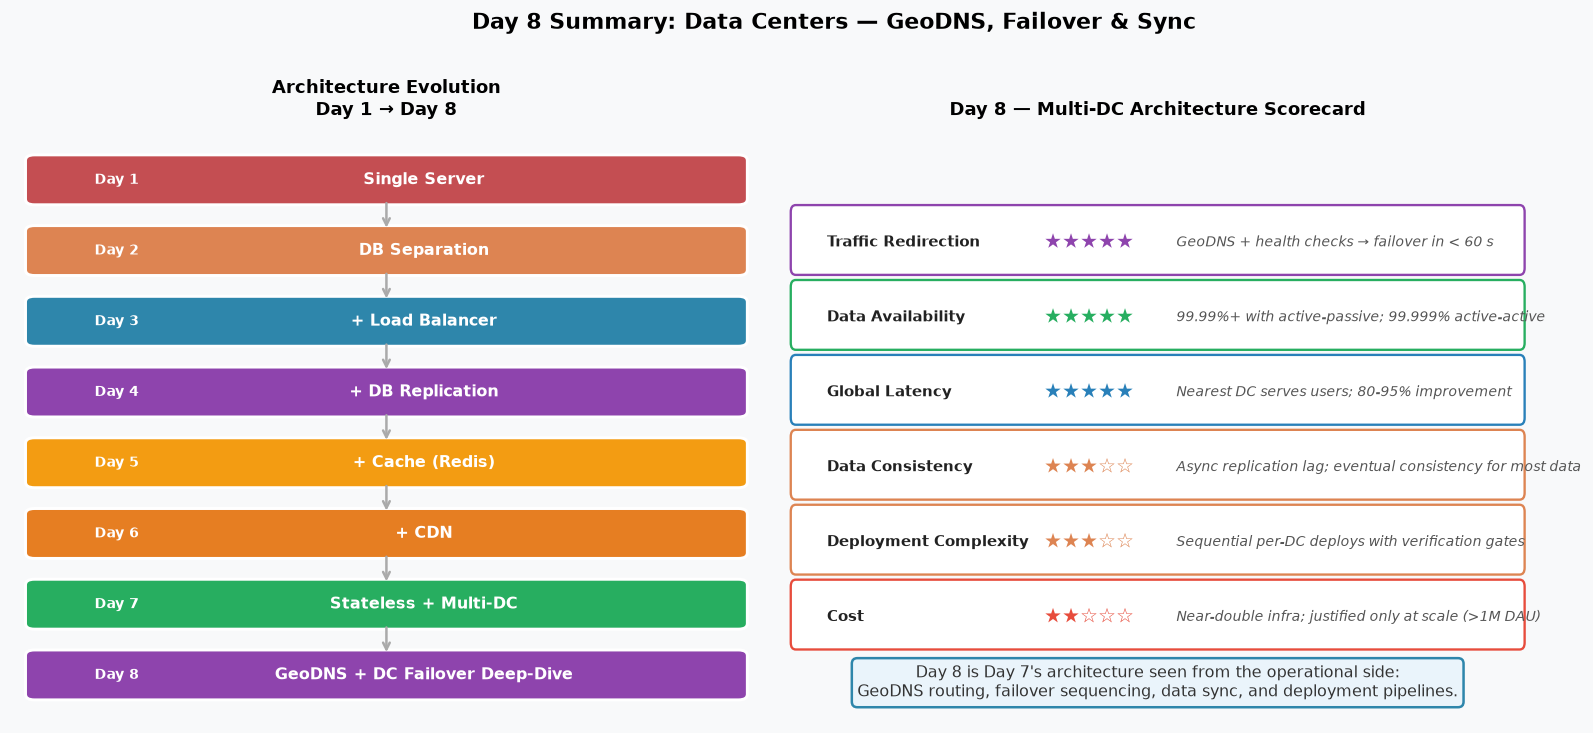

Day 8 complete.


In [8]:
# Day 8 Scorecard + Evolution Day 1 -> 8

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 8', fontsize=11, fontweight='bold')

days = [
    ('Day 1', 'Single Server',                      '#C44E52'),
    ('Day 2', 'DB Separation',                      '#DD8452'),
    ('Day 3', '+ Load Balancer',                    '#2E86AB'),
    ('Day 4', '+ DB Replication',                   '#8E44AD'),
    ('Day 5', '+ Cache (Redis)',                    '#F39C12'),
    ('Day 6', '+ CDN',                              '#E67E22'),
    ('Day 7', 'Stateless + Multi-DC',               '#27AE60'),
    ('Day 8', 'GeoDNS + DC Failover Deep-Dive',     C_DNS),
]
ys = np.linspace(11.8, 1.0, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 8 — Multi-DC Architecture Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Traffic Redirection',  '★★★★★', C_DNS,
     'GeoDNS + health checks → failover in < 60 s'),
    ('Data Availability',    '★★★★★', C_DC2,
     '99.99%+ with active-passive; 99.999% active-active'),
    ('Global Latency',       '★★★★★', C_DC1,
     'Nearest DC serves users; 80-95% improvement'),
    ('Data Consistency',     '★★★☆☆', C_ORANGE,
     'Async replication lag; eventual consistency for most data'),
    ('Deployment Complexity','★★★☆☆', C_ORANGE,
     'Sequential per-DC deploys with verification gates'),
    ('Cost',                 '★★☆☆☆', C_FAIL,
     'Near-double infra; justified only at scale (>1M DAU)'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.9,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.3,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Day 8 is Day 7\'s architecture seen from the operational side:\n'
        'GeoDNS routing, failover sequencing, data sync, and deployment pipelines.',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.suptitle('Day 8 Summary: Data Centers — GeoDNS, Failover & Sync',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day8_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 8 complete.")


### What this shows

**Left — Evolution Day 1 → Day 8:**  
Day 8 builds on Day 7's stateless + multi-DC foundation by going deeper on the operational mechanics: GeoDNS resolution, failover sequencing, data sync strategies, and deployment pipelines. The architecture diagram itself is the same; Day 8 teaches you how to operate it.

**Right — Day 8 Scorecard:**
- **Traffic Redirection (5/5):** GeoDNS + health checks → sub-2-minute failover.
- **Data Availability (5/5):** 99.99% with active-passive; 99.999% with active-active.
- **Global Latency (5/5):** Nearest DC serves requests; latency improvements exceed 80%.
- **Data Consistency (3/5):** Async replication means eventual consistency is the default.
- **Deployment Complexity (3/5):** Sequential per-DC pipelines with manual gates add lead time.
- **Cost (2/5):** Near-double infrastructure cost — justified at scale but expensive early.

**Key insight:** Day 8 and Day 7 cover the same architecture from two different angles. Day 7 asks *what* to build (stateless, multi-DC). Day 8 asks *how to operate it* (GeoDNS routing, failover, sync, deployment).